In [2]:
# import the usual suspects
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing


In [3]:
import sys
sys.path.append('..')

In [4]:
import dice_ml
import time

In [5]:
config = load_config("config.yaml")


In [6]:
dataset_name = 'toy_dataset'
dataset_name = 'german_credit'

In [7]:
data_processor = DataProcessor(config=config)


In [8]:
splits_path = f"data/processed/{dataset_name}/y_train.npz"
if not check_file_exists(splits_path):
    print(splits_path,"not found")
    print("Processing dataset")
    data = data_processor.load_dataset(dataset_name)
    processed_data = data_processor.preprocess_data(data,
                                                    dataset_name)
    splits = data_processor.split_data(features=processed_data[0],
                                        target=processed_data[1])
    data_processor.save_splits(splits, dataset_name)
else:
    print("Loading existing dataset")
    splits = data_processor.load_splits(dataset_name)

# print the balance of the splits
print("Train balance: \n")
print_balancing(splits['y_train'])
print("Test balance: \n")
print_balancing(splits['y_test'])
print("Calibration balance: \n")
print_balancing(splits['y_calibration'])



Loading existing dataset
Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz
Train balance: 

Balancing: 550 samples
|██████████████      | class 0: 385 (70.0%)
|              ██████| class 1: 165 (30.0%)

Test balance: 

Balancing: 250 samples
|██████████████      | class 0: 175 (70.0%)
|              ██████| class 1: 75 (30.0%)

Calibration balance: 

Balancing: 200 samples
|██████████████      | class 0: 140 (70.0%)
|              ██████| class 1: 60 (30.0%)



(array([0, 1]), array([140,  60]))

In [9]:
# import the importing module to import the modules for the notebook
from importlib import reload
import src.cp_ils as cpils


In [10]:
model_trainer = ModelTrainer(config=config)
random_F = model_trainer._load_model("random_forest", dataset_name)

xbg = model_trainer._load_model("xgboost", dataset_name)
mlp = model_trainer._load_model("mlp", dataset_name)
lgbm = model_trainer._load_model("lgbm", dataset_name)
models = {"random_forest": random_F,
          "xgboost": xbg,
          "mlp": mlp,
          "lgbm": lgbm}

Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded mlp model from models/german_credit/mlp.pkl
Loaded lgbm model from models/german_credit/lgbm.pkl


In [59]:
from src.cf_generator_ils import IlsCFGenerator

cf_generator = IlsCFGenerator(config,dataset_name)
reference_set = splits['X_train'].copy()
feat_names = splits['X_train'].columns.to_list()
target_name = data_processor.target_name
# we add the target variable to the reference set
reference_set[target_name] = splits['y_train']
cf_generator.setup(
    reference_data=reference_set,
    #feature_names=feat_names,
    continuous_features = feat_names,
    categorical_features=[],#data_processor.categorical_features,
    target_name=target_name,
)


In [60]:

old_splits = {}
old_splits["X_calibration"] = splits["X_calibration"].copy()
old_splits["X_train"] = splits["X_train"].copy()

In [61]:
#np.abs(splits['X_calibration']).max(axis=0),np.abs(splits['X_train']).max(axis=0),np.abs(old_splits['X_calibration']).max(axis=0)

In [ ]:
models = {"mlp": mlp,}
print("Generating counterfactuals")
counterfactuals = cf_generator.generate_counterfactuals(
        models=models,
        X_calibration=splits['X_calibration'][4:8].copy(),
        y_calibration=splits['y_calibration'][4:8].copy(),
        num_cf=8,
        dt_name=dataset_name,
        set_name="calibration"
    )


Generating counterfactuals
Generating CFs with with method: (latent) for model: mlp
trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_german_credit_mlp_Ls_2.pkl
Loaded component from counterfactuals/cf_generators/ils/ils_explainer_german_credit_mlp_Ls_2.pkl
Explainer model found. Loading existing ILS.
Explainer model loaded.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [275]:
np.abs(splits['X_calibration']).max(axis=0),np.abs(splits['X_train']).max(axis=0),np.abs(old_splits['X_calibration']).max(axis=0)

(Feature1    2.361175
 Feature2    2.307715
 dtype: float64,
 Feature1    2.346455
 Feature2    2.624443
 dtype: float64,
 Feature1    2.361175
 Feature2    2.307715
 dtype: float64)

In [278]:
# assert the old splits are the same as the new splits
assert np.allclose(old_splits['X_train'], splits['X_train']),"Train has changed"
assert np.allclose(old_splits['X_calibration'], splits['X_calibration']),"Calibration has changed"

In [279]:
cf_generator._explainers["mlp"].bb_predict(splits['X_calibration'][:].values)

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1])

In [280]:
weights, Z_cal = cf_generator._explainers["mlp"].transform(splits['X_calibration'][:].values)
# models["lgbm"].predict(splits['X_calibration'][:].values)
latent = cf_generator._explainers["mlp"]

In [281]:
latent._predict(Z_cal)

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1])

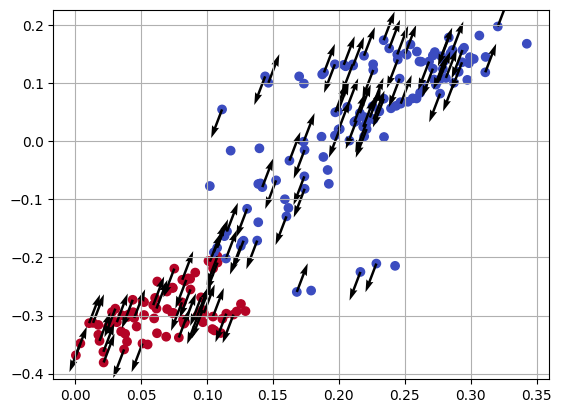

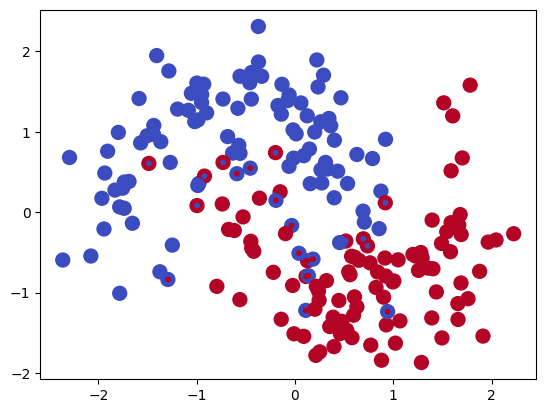

In [283]:
plt.scatter(Z_cal[:,0], Z_cal[:,1], c=latent._predict(Z_cal), cmap='coolwarm')
for idx in np.random.choice(Z_cal.shape[0], 100, replace=False):
    w = weights.copy()
    y_contrib = w[:,-1]/np.linalg.norm(w[:,-1])
    if latent.y_train_bb[idx]>0.5:
        y_contrib *=-1
    plt.quiver(Z_cal[idx,0], Z_cal[idx,1],
                y_contrib[0], y_contrib[1], angles='xy', scale_units='xy', width=5*1e-3, scale=20)
plt.grid()

plt.show()
# now plot the original data
plt.scatter(old_splits['X_calibration'][:].values[:,0], 
            old_splits['X_calibration'][:].values[:,1], c=splits['y_calibration'][:], cmap='coolwarm',s=100)
plt.scatter(splits['X_calibration'][:].values[:,0], 
            splits['X_calibration'][:].values[:,1], c=models["mlp"].predict(old_splits['X_calibration'][:].values), cmap='coolwarm',s=10)

In [284]:

splits['X_calibration'],old_splits['X_calibration']


(     Feature1  Feature2
 0   -0.987172  1.146316
 1    0.629517 -1.176607
 2    0.089794  0.701431
 3   -1.193523  1.281047
 4    0.060297  1.357221
 ..        ...       ...
 195  0.606865 -0.560137
 196 -0.949545  1.362708
 197  0.788379  0.665795
 198  1.354007 -0.695482
 199  1.286096 -1.868652
 
 [200 rows x 2 columns],
      Feature1  Feature2
 0   -0.987172  1.146316
 1    0.629517 -1.176607
 2    0.089794  0.701431
 3   -1.193523  1.281047
 4    0.060297  1.357221
 ..        ...       ...
 195  0.606865 -0.560137
 196 -0.949545  1.362708
 197  0.788379  0.665795
 198  1.354007 -0.695482
 199  1.286096 -1.868652
 
 [200 rows x 2 columns])

In [285]:
np.abs(splits['X_calibration']).max(axis=0),np.abs(splits['X_train']).max(axis=0),np.abs(old_splits['X_calibration']).max(axis=0)

(Feature1    2.361175
 Feature2    2.307715
 dtype: float64,
 Feature1    2.346455
 Feature2    2.624443
 dtype: float64,
 Feature1    2.361175
 Feature2    2.307715
 dtype: float64)

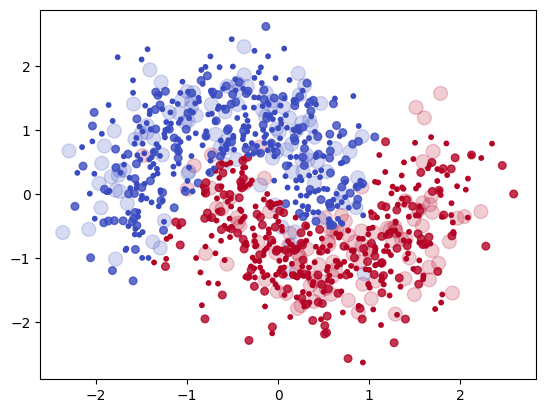

In [287]:
plt.scatter(splits['X_calibration'][:].values[:,0], splits['X_calibration'][:].values[:,1], c=splits['y_calibration'][:], cmap='coolwarm',s=100,alpha=0.2)
plt.scatter(splits['X_test'][:].values[:,0], splits['X_test'][:].values[:,1], c=models["mlp"].predict(splits['X_test'][:].values), cmap='coolwarm',s=30,alpha=0.8)
plt.scatter(splits['X_train'][:].values[:,0], splits['X_train'][:].values[:,1], c=models["mlp"].predict(splits['X_train'][:].values), cmap='coolwarm',s=10)


In [11]:
'''
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(splits['X_train'],splits['y_train'])
models = {"mlp": mlp, "decision_tree": dt}
plot_tree(dt,filled=True,feature_names=splits['X_train'].columns)
plt.show()
'''

'\nfrom sklearn.tree import DecisionTreeClassifier,plot_tree\ndt = DecisionTreeClassifier(max_depth=4)\ndt.fit(splits[\'X_train\'],splits[\'y_train\'])\nmodels = {"mlp": mlp, "decision_tree": dt}\nplot_tree(dt,filled=True,feature_names=splits[\'X_train\'].columns)\nplt.show()\n'

In [12]:
cf_generator._load_component("counterfactuals/cf_generators/dice/german_credit/")

In [13]:
cf_method = 'random'
experiments = {m:{meth:[0,[np.inf]] for meth in ["random","kdtree","genetic"]} for m in ["mlp","xgboost","random_forest","lgbm"]}
experiments,cf_method 

({'mlp': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]},
  'xgboost': {'random': [0, [inf]],
   'kdtree': [0, [inf]],
   'genetic': [0, [inf]]},
  'random_forest': {'random': [0, [inf]],
   'kdtree': [0, [inf]],
   'genetic': [0, [inf]]},
  'lgbm': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]}},
 'random')

In [14]:
'''# now we redo all that the counterfactuals generator object does
# for the sake of clarity and checking the time
import dice_ml
reference_data = splits['X_train'].sample(1)

reference_data["target"] = 1

# reference_data = splits['X_train'].copy()
# reference_data["target"] = splits['y_train']
dice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits['X_train'].columns+["target"]),
                         continuous_features=splits['X_train'].columns.to_list(),
                         categorical_features=[],
                         outcome_name='target',
                         dataset_name='german_credit')

dice_model = dice_ml.Model(model=models["mlp"],
                            backend="sklearn")
explainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)

counterfactuals = cf_generator.generate_counterfactuals(
        models,
        splits['X_calibration'],
        splits['y_calibration'],
        "random",
        dt_name=dataset_name
    )'''

'# now we redo all that the counterfactuals generator object does\n# for the sake of clarity and checking the time\nimport dice_ml\nreference_data = splits[\'X_train\'].sample(1)\n\nreference_data["target"] = 1\n\n# reference_data = splits[\'X_train\'].copy()\n# reference_data["target"] = splits[\'y_train\']\ndice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits[\'X_train\'].columns+["target"]),\n                         continuous_features=splits[\'X_train\'].columns.to_list(),\n                         categorical_features=[],\n                         outcome_name=\'target\',\n                         dataset_name=\'german_credit\')\n\ndice_model = dice_ml.Model(model=models["mlp"],\n                            backend="sklearn")\nexplainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)\n\ncounterfactuals = cf_generator.generate_counterfactuals(\n        models,\n        splits[\'X_calibration\'],\n        splits[\'y_calibration\'],\n        "ra

In [15]:
'''

for i in range(total_samples):
        e = splits['X_calibration'].loc[[i]]
        try:
            res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)
            print(len(res.cf_examples_list[0].final_cfs_df))

            found+=1
        except Exception as exc:
            print(exc)
            continue
            #print(exc,", skipping")
print("Found",found,"counterfactuals", "out of",total_samples)
print("percentage",found/total_samples)'''

'\n\nfor i in range(total_samples):\n        e = splits[\'X_calibration\'].loc[[i]]\n        try:\n            res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)\n            print(len(res.cf_examples_list[0].final_cfs_df))\n\n            found+=1\n        except Exception as exc:\n            print(exc)\n            continue\n            #print(exc,", skipping")\nprint("Found",found,"counterfactuals", "out of",total_samples)\nprint("percentage",found/total_samples)'

In [16]:
experiments

{'mlp': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]},
 'xgboost': {'random': [0, [inf]],
  'kdtree': [0, [inf]],
  'genetic': [0, [inf]]},
 'random_forest': {'random': [0, [inf]],
  'kdtree': [0, [inf]],
  'genetic': [0, [inf]]},
 'lgbm': {'random': [0, [inf]], 'kdtree': [0, [inf]], 'genetic': [0, [inf]]}}

In [19]:
found=0
total_samples = 25
percs = [1,25,50,100]
full_experiments = {p:{} for p in percs}
results = {}
for percentage in percs:
    results[percentage] = {}
    #########################
    #### CHOOSE THE DATA ####
    #########################
    if percentage==1:
        reference_data = splits['X_train'].sample(1)
        reference_data["target"] = 1
    else:
        # choose a percentage of the training data

        choosen_idxs = np.random.choice(splits['X_train'].index, int(len(splits['X_train'])*percentage/100))
        reference_data = splits['X_train'].loc[choosen_idxs]
        reference_data["target"] = splits['y_train'].loc[choosen_idxs]
    dice_data = dice_ml.Data(dataframe=reference_data,#pd.DataFrame([], columns=splits['X_train'].columns+["target"]),
                            continuous_features=splits['X_train'].columns.to_list(),
                            categorical_features=[],
                            outcome_name='target',
                            dataset_name='german_credit')

    #########################
    #### CHOOSE THE MODEL ###
    #########################
    experiments = {m:{meth:[0,[np.inf]] for meth in ["random","kdtree","genetic"]} for m in ["mlp","xgboost","random_forest","lgbm"]}
    for cf_method in ["random","kdtree"]:#,"genetic"]: 
        results[percentage][cf_method] = {}
        for model in ["random_forest"]:
            results[percentage][cf_method][model] = {}
            print("Generating counterfactuals for",model,"with",cf_method,"method with",percentage,"% of the training data")
            dice_model = dice_ml.Model(model=models["mlp"],
                                    backend="sklearn")
            explainer = dice_ml.Dice(dice_data, dice_model, method=cf_method)

            found=0
            times = []
            founded = []
            oupts = []
            for i in range(total_samples):
                e = splits['X_calibration'].loc[[i]]
                
                try:
                    start = time.time()
                    res = explainer.generate_counterfactuals(e, total_CFs=32, desired_class="opposite",verbose=False)
                    print(len(res.cf_examples_list[0].final_cfs_df))
                    oupts.append(res)
                    found+=1
                    founded.append(1)
                except Exception as exc:
                    print(exc)
                    founded.append(0)
                    continue

                elapsed = time.time()-start
                
                '''
                # to test the time and the founds invent the data
                foundq = np.random.randint(0,2)
                found+=foundq
                founded.append(foundq)
                elapsed = np.random.rand()*10
                '''
                times.append(elapsed)
            print("Found",found,"counterfactuals", "out of",total_samples)
            print("percentage",found/total_samples)

            experiments[model][cf_method][0] = np.array(founded)
            experiments[model][cf_method][1] = np.array(times)
            results[percentage][cf_method][model]["found"] = founded
            results[percentage][cf_method][model]["times"] = times
            results[percentage][cf_method][model]["outputs"] = oupts
    full_experiments[percentage] = experiments


Generating counterfactuals for random_forest with random method with 1 % of the training data


100%|██████████| 1/1 [00:00<00:00,  3.58it/s]


32


100%|██████████| 1/1 [00:00<00:00,  3.60it/s]


32


...

32


100%|██████████| 1/1 [01:49<00:00, 109.25s/it]


32


100%|██████████| 1/1 [03:44<00:00, 224.38s/it]

32
Found 25 counterfactuals out of 25
percentage 1.0


In [21]:
import seaborn as sns

In [46]:
def write_time(s):
        s = np.round(s,2)
        if s<60:
            return str(s)+"s"
        elif s<60*60:
            s = np.round(s/60,2)
            return str(s)+"m"
        else:
            s = np.round(s/60/60,2)
            return str(s)+"h"

In [76]:
percs

[1, 25, 50, 100]

100.0
100.0
100.0
100.0
Total time needed: 7.72s 36.45m 42.87m 53.12m


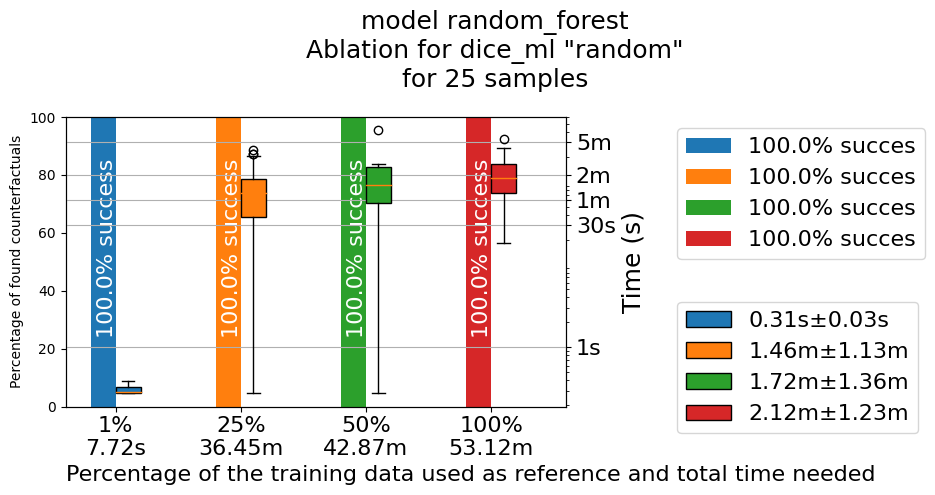

In [79]:
# define the figure
for meth in ["random"]:
    fig, ax = plt.subplots(1,1,figsize=(10,5))
    ax2 = ax.twinx()
    all_percs = []
    all_times = []
    labs = []
    boxes = []

    for idx,i in enumerate(percs):
        # get the experiment:
        exp = full_experiments[i]    
        # plot the bars relatively to the total samples
        # at the j-th position
        percentages = exp["random_forest"]["random"][0].sum()/total_samples*100
        print(percentages)
        ax.bar(idx-0.2,percentages,0.2,label=str(round(percentages,2))+"% succes")
        text_position = (idx-0.25,percentages/4)
        # write in white the percentage of found counterfactuals
        ax.text(*text_position,str(round(percentages,2))+"% success",color="white",fontsize=16,rotation=90)
        ax.set_ylabel("Percentage of found counterfactuals")
        # plot the boxplot of the times
        # get the ax2
        cmap = sns.color_palette("tab10", as_cmap=True)
        times = exp["random_forest"][meth][1]
        pathc = ax2.boxplot(times,positions=[idx],widths=0.2,patch_artist=True,showfliers=True)
        labs.append(write_time(np.mean(times))+"±"+
                    write_time(np.std(times)))
        all_times.append(times)
        for patch in pathc['boxes']:
            patch.set_facecolor(cmap(idx))
        boxes.append(pathc["boxes"][0])
        ax2.set_ylabel("Time (s)",fontsize=18)
        all_percs.append(percentages)
    
    ax.set_ylim(0,100)
    # make the legend external
    ax.legend(loc='upper left', bbox_to_anchor=(1.2, 1),fontsize=16)
    ax2.legend(boxes,labs,loc='upper left', bbox_to_anchor=(1.2, 0.4),fontsize=16)

    # set the y ticks to be at 1 second, 30, 60, 120.
    # use as labels 1s, 30s, 1m, 2m
    ax2.set_yscale("log")
    ax2.set_yticks([1,30,60,120,60*5])
    ax2.set_yticklabels(["1s","30s","1m","2m","5m"],fontsize=16)
    all_times_s = [ii.sum() for ii in all_times]
    
    additional_label = "Total time needed: "+" ".join(map(write_time,all_times_s))
    xticks = [str(p)+"%\n"+(t_s) for p,t_s in zip(percs,map(write_time,all_times_s))]
    #ax.set_xticks(np.arange(len(percs))-.1,[str(p)+"%" for p in percs],fontsize=16)
    ax.set_xticks(np.arange(len(percs))-.1,xticks,fontsize=16)
    ax.set_xlabel("Percentage of the training data used as reference and total time needed",fontsize=16,loc="left")
    plt.suptitle("model random_forest\n Ablation for dice_ml \""+str(meth)+"\" \nfor 25 samples",fontsize=18)
    plt.tight_layout()
    # show the grid
    plt.grid(True)
    date = time.strftime("%Y-%m-%d-%H-%M-%S")

    spath = f"plots/ablation_random_forest_{meth}_dice_ml_"+date+".pdf"
    plt.savefig(spath)
    print(additional_label)

In [72]:
date = time.strftime("%Y-%m-%d-%H-%M-%S")
date.replace("-","")

'20241204185530'